In [1]:
import math
import numpy as np
import random
import time
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib.patches import Ellipse
from itertools import chain
import time
from operator import attrgetter
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

In [2]:
# surface functions, merge function, and other helper functions

def surface_single(x, U, A, p=2):
    """
    Compute the hyperellipsoid surface function for a single point.

    Parameters
    ----------
    x : np.ndarray, shape (d,)
        The query point.
    U : np.ndarray, shape (d, d)
        Eigenvectors (columns) defining the ellipsoid orientation.
    A : np.ndarray, shape (d,)
        Semi-axis lengths along each eigenvector direction.

    Returns
    -------
    float
        < 0 if x is inside the ellipsoid
        = 0 if x is on the surface
        > 0 if x is outside the ellipsoid
    """
    x_local = U.T @ x        # Project into ellipsoid's local frame, shape (d,)
    return np.sum(np.abs(x_local / A) ** p) - 1

def surface_multi(xs, Us, As, p=2):
    """
    Compute the hyperellipsoid surface function for n points,
    each against its own ellipsoid.

    Parameters
    ----------
    xs : np.ndarray, shape (n, d)
        Query points.
    Us : np.ndarray, shape (n, d, d)
        Per-ellipsoid eigenvector matrices.
    As : np.ndarray, shape (n, d)
        Per-ellipsoid semi-axis lengths.

    Returns
    -------
    np.ndarray, shape (n,)
        Surface function value for each (point, ellipsoid) pair.
        < 0 inside, = 0 on surface, > 0 outside.
    """
    xs_local = np.einsum('ndi, ni -> nd', Us.swapaxes(1,2), xs)  # (n, d)
    return np.sum(np.abs(xs_local / As) ** p, axis=1) - 1              # (n,)

def merge_nodes(x, y): # NOTE: New P is currently avg of the 2 that is (x.p + y.p) / 2
    new_n = x.n + y.n
    dist = x.M - y.M
    new_M = ((x.n * x.M) + (y.n * y.M)) / (new_n)
    new_S = ((x.n / new_n) * x.S) + ((y.n / new_n) * y.S) + (((x.n * y.n)/ (new_n ** 2)) * (np.outer(dist, dist)))
    eigen_value, eigen_vector = np.linalg.eigh(new_S)
    # reverse the order of the eigenvalue/vectors to be in DESCENDING order
    eigen_value = eigen_value[::-1]
    eigen_vector = eigen_vector[:, ::-1]
    # eigen_vector = eigen_vector.T
    new_A = np.sqrt(np.pi * 2 * np.abs(eigen_value))
    new_A[new_A == 0] = x.eps

    return Node(dimension=x.dim, label=x.label, A=new_A, n=new_n, M=new_M, S=new_S, U=eigen_vector, eps=x.eps, alpha=x.alpha, p=(x.p + y.p) / 2)

def print_stat(arr, name):
    print(f"{name} Mean:", np.mean(arr))
    print(f"{name} Max:", np.max(arr))
    print(f"{name} Min:", np.min(arr))

def print_time(arr, name):
    print(f"action: {name}")
    print(f"count: {len(arr)}")
    print(f"total: {sum(arr)}")
    print(f"avg: {sum(arr)/len(arr)}")

def train_test_split(ds, test_ratio=0.2):
    ds = ds[:]  # copy
    random.shuffle(ds)

    split_idx = int(len(ds) * (1 - test_ratio))
    return ds[:split_idx], ds[split_idx:]



In [3]:
class Node():
    def __init__(self,
        dimension, label,
        A, p, eps, alpha,
        n=1,
        M=None,
        S=None,
        U=None):
        """
        A node contain information about a single ellipsoid such as its centre, cov matrix, and the axis length andd direction.
        It can be "updated" with a point to move it to learn and cover more data point.
        
        Parameters
        A (np.ndarray) (dim) : The length of each axis. Not necessary sorted.  np array 
        p (np.ndarray) (dim) : The power/exponent the nth term of the ellipsoid will be raised to when calculating surface function.
        eps (float) : A small value to add to the axis length when calculating surface function to avoid div by zero.
        alpha (float) : A hyperparameter between [0, 1] to control how the axis length is updated.
                        It specify the weight between "fixed" and "dynamic" update rule.
                        For more information see (Wongsriphisant, et al. 2026) https://doi.org/10.1016/j.eswa.2025.129818
        n (int) : The number of data points this node has learnt from.
        U (np.ndarray) (dim, dim) : The eigenvectors of the cov matrix. NOT transposed that is U[i] contain the ith eigenvector.
        M (np.ndarray) (dim) : The mean/center of the ellipsoid
        S (np.ndarray) (dim, dim) : The cov matrix of the ellipsoid. 
        """

        self.dim = dimension
        self.label = label
        self.A = A
        self.p = p
        self.eps = eps
        self.alpha = alpha
        self.n = n

        self.U = np.eye(dimension) if U is None else U
        self.M = np.array([0.] * dimension) if M is None else M
        self.S = np.zeros((dimension, dimension)) if S is None else S

    def update(self, x, parent):
        """
        Update the node with a new data point x.
        Performing the following steps.
        1. Calculate the new mean and cov matrix of the node including the new point
        2. Calculate the eigenvalue/vector of the new cov matrix
        3. Update the width of the axes of the ellipsoid
        4. Calculate the growth criterion to check whether the updated ellipsoid cover the new data point
        5. If the growth criterion is acceptable the node is allowed to grow/update to include this new data point,
           else the node is not updated and a new node is added to cover the new datapoint instead.

        Parameter
        x (np.ndarray) (dim) : A new data point the model need to learn/update from.
        parent (VEBF) : The VEBF model this node belong to. We only need this in case we need to add a new node to the VEBF model. 
        """

        # Calculate new mean and cov matrix
        n = self.n
        M = self.M
        alpha = n / (n + 1)
        beta = x / (n + 1)
        M_new = (alpha * M) + beta
        k_1 = (np.outer(x, x)/(n + 1)) - np.outer(M_new, M_new) + np.outer(M, M)
        k_2 = - (np.outer(M, M) / (n + 1))
        k = k_1 + k_2
        S_new = (alpha * self.S) + k

        eigen_value, eigen_vector = np.linalg.eigh(S_new)
        # reverse the order of the eigenvalue/vectors to be in DESCENDING order
        eigen_value = eigen_value[::-1]
        eigen_vector = eigen_vector[:, ::-1]

        # calculate new width with adaptively by combining fixed and dynamic width update rules
        beta = 1 - self.alpha
        fixed = np.sqrt(np.pi * 2 * np.abs(eigen_value))
        dynamic = self.A + ((M_new - self.M) @ eigen_vector.T)
        new_A = (self.alpha * fixed) + (beta * dynamic)
        new_A[new_A == 0] = self.eps
        
        gc = surface_single(x - M_new, eigen_vector, self.A, self.p)
        if gc <= 0:
            # update the current node
            self.M = M_new
            self.U = eigen_vector
            self.S = S_new
            self.A = new_A
            self.n += 1
            return self
        else:
            # add new node
            new_node = Node(self.dim, self.label, M=x, eps=self.eps, A=parent.default_width, alpha=self.alpha, p=self.p)
            parent.nodes[self.label].append(new_node)
            return new_node

    def __str__(self):
        return f"A node covering {self.n} points."

In [4]:
class VEBF():
    def __init__(self, dimension, merge_parameter=0, eps=0.00001, default_width=None, alpha=0.55, p=None):
        """
        The Versatile Ellipsoid Basis Function model.
        Geometrically, the model learn by covering the datapoints with ellipsoids to learn the distribution of the data.
        
        Parameter
        dimension (int) : Number of dimension of input feature.
        merge_parameter (float) : The hyperparameter that controll when two ellipsoids/nodes will be merged.
        p (np.ndarray) (dim) : The power/exponent the nth term of the ellipsoid will be raised to when calculating surface function. (dim) np array
        eps (float) : A small value to add to the axis length when calculating surface function to avoid div by zero.
        alpha (float) : A hyperparameter between [0, 1] to control how the axis length is updated.
                        It specify the weight between "fixed" and "dynamic" update rule.
                        For more information see (Wongsriphisant, et al. 2026) https://doi.org/10.1016/j.eswa.2025.129818
        default_width (np.ndarray) (dim) : The default axis width of the ellipsoid.
        """
        self.dim = dimension
        self.merge_parameter = merge_parameter
        self.nodes = {}
        self.eps = eps
        self.alpha = alpha
        self.default_width = np.array([1.] * dimension) if default_width is None else default_width
        self.p = np.array([2.] * dimension) if p is None else p # default to "normal" hyperellipsoid with p=2

    def find_shortest(self, x, y):
        # TODO: vectorize this
        min_dist = float('inf')
        min_node = None
        for node in self.nodes[y]:
            dist = np.linalg.norm(node.M - x)
            if dist < min_dist:
                min_dist = dist
                min_node = node
        return min_node

    # NOTE: can combine this with find_shortest by using y=None as default value
    def find_shortest_all(self, x, nodes=None):
        min_dist = float('inf')
        min_node = None
        nodes = self.get_nodes() if nodes is None else nodes
        for node in nodes:
            dist = np.linalg.norm(node.M - x)
            if dist < min_dist:
                min_dist = dist
                min_node = node
        return min_node

    def check_merge(self, x):
        """
        Check for pair of nodes which can be merged.
        Only consider the "latest" node, x

        Parameters:
        x (Node): The node which has just been updated or created.
        """
        nodes = self.nodes[x.label]
        if len(nodes) == 1:
            return
        nodes.remove(x)

        Us = np.array([node.U for node in nodes])
        Ms = np.array([node.M for node in nodes])
        As = np.array([node.A for node in nodes])
        Ps = np.array([node.p for node in nodes])
        
        scores = surface_multi(x.M - Ms, Us, As, Ps)
        merge_candidates = [node for node, score in zip(nodes, scores) if score <= self.merge_parameter]
        if len(merge_candidates) > 0:
            y = merge_candidates[0]
            nodes.remove(y)
            new_node = merge_nodes(x, y)
            nodes.append(new_node)
            self.check_merge(new_node)
            return

        n = len(nodes)
        U = x.U
        A = x.A
        P = x.p
        Us = np.broadcast_to(U, (n,) + U.shape)
        As = np.broadcast_to(A, (n,) + A.shape)
        Ps = np.broadcast_to(P, (n,) + P.shape)

        scores = surface_multi(Ms - x.M, Us, As, Ps)
        merge_candidates = [node for node, score in zip(nodes, scores) if score <= self.merge_parameter]
        if len(merge_candidates) > 0:
            y = merge_candidates[0]
            nodes.remove(y)
            new_node = merge_nodes(y, x)
            nodes.append(new_node)
            self.check_merge(new_node)
            return
            
        nodes.append(x)

    def get_nodes(self):
        return list(chain.from_iterable(self.nodes.values()))

    def predict(self, x):

        nodes = self.get_nodes()
        Us = np.array([node.U for node in nodes])
        Ms = np.array([node.M for node in nodes])
        As = np.array([node.A for node in nodes])
        Ps = np.array([node.p for node in nodes])

        scores = surface_multi(x - Ms, Us, As, Ps)
        candidates = [node for node, score in zip(nodes, scores) if score <= 0]

        if len(candidates) == 0:
            closest = self.find_shortest_all(x)
            return closest.label
        return self.find_shortest_all(x, candidates).label
            
    def train(self, x, y):
        if y not in self.nodes: # Add a new node for unseen label.
            self.nodes[y] = [Node(dimension=self.dim, label=y, M=x, eps=self.eps, A=self.default_width, alpha=self.alpha, p=self.p)]
        else: # Update closest existing node for existing label.
            shortest = self.find_shortest(x, y)
            latest = shortest.update(x, self) # latest is the node with latest change, which need to checked for merge
            self.check_merge(latest)

    def __str__(self):
        total = sum(len(x) for x in self.nodes.values())
        string = f"A vebf with {total} nodes.\n"
        for label, nodes in self.nodes.items():
            for node in nodes:
                string += f"Label {label}: {str(node)}\n"
        return string

In [5]:
# loading datasets and setting hyperparameters

iris_dim = 4
ecoli_dim = 7
yeast_dim = 8
wave_dim = 21

# initial Axis length (delta * average euclidean distance of all points, where delta is 1 for all ds except iris=1/3) 
# See (Jaiyen, et al 2010)
iris_A = np.array([2.5] * iris_dim)
ecoli_A = np.array([1.2] * ecoli_dim)
yeast_A = np.array([0.75] * yeast_dim)
wave_A = np.array([9.69] * wave_dim)

# power for each to raise each term in the ellipsoid to.
# Baseline Setting (p = 2)
iris_P = np.array([2.] * iris_dim)
ecoli_P = np.array([2.] * ecoli_dim)
yeast_P = np.array([2.] * yeast_dim)
wave_P = np.array([2.] * wave_dim)

# Currently using same p for all terms but varying p between each run

with open("data/iris/iris.data", "r") as f:
    iris_data = f.readlines()
iris_ds = []
for line in iris_data[:-1]:
    line = line.strip().split(',')
    x = np.array(line[:-1], dtype=float)
    y = line[-1]
    iris_ds.append((x, y))

with open("data/ecoli/ecoli.data", "r") as f:
    ecoli_data = f.readlines()
ecoli_ds = []
for line in ecoli_data:
    line = line.strip().split()
    x = np.array(line[1:-1], dtype=float)
    y = line[-1]
    ecoli_ds.append((x, y))

with open("data/image_seg/segmentation.data", "r") as f:
    seg_train_data = f.readlines()
with open("data/image_seg/segmentation.test", "r") as f:
    seg_test_data = f.readlines()
seg_train = []
for line in seg_train_data[5:]:
    line = line.strip().split(",")
    y = line[0]
    x = np.array(line[1:], dtype=float)
    seg_train.append((x, y))
seg_test = []
for line in seg_test_data[5:]:
    line = line.strip().split(",")
    y = line[0]
    x = np.array(line[1:], dtype=float)
    seg_test.append((x, y))

with open("data/waveform/waveform.data", "r") as f:
    waveform_data = f.readlines()
waveform_ds = []
for line in waveform_data:
    line = line.strip().split(",")
    y = line[-1]
    x = np.array(line[:-1], dtype=float)
    waveform_ds.append((x, y))

with open("data/yeast/yeast.data", "r") as f:
    yeast_data = f.readlines()
yeast_ds = []
for line in yeast_data:
    line = line.strip().split()
    x = np.array(line[1:-1], dtype=float)
    y = line[-1]
    yeast_ds.append((x, y))

In [6]:
Ps = [i for i in np.arange(0.1, 10.1, 0.1)]

In [39]:
def plot_superellipsoid_2d(
    C: np.ndarray,
    U: np.ndarray,
    A: np.ndarray,
    P: np.ndarray,
    ax=None,
    resolution: int = 500,
    fill: bool = False,
    fill_alpha: float = 0.25,
    color: str = "steelblue",
    label: str = None,
):
    """
    Visualize a 2-D superellipsoid defined by the implicit function:

        f(x, y) = |u1 · (r - C) / a1|^p1 + |u2 · (r - C) / a2|^p2  ≤  1

    where u1, u2 are the columns of U (axis directions).

    Parameters
    ----------
    C : ndarray, shape (2,)
        Center of the superellipsoid.
    U : ndarray, shape (2, 2)
        Each *column* is a unit vector giving the direction of an axis.
        (Follows the convention where U[:, i] is the i-th axis direction.)
    A : ndarray, shape (2,)
        Half-lengths along each axis.
    P : ndarray, shape (2,)
        Exponents [p1, p2].  p=2 gives an ellipse; p→∞ gives a rectangle;
        0 < p < 2 gives a "pinched" / star shape.
    ax : matplotlib Axes, optional
        Target axes.  A new figure is created when None.
    resolution : int
        Number of grid points per axis for the implicit-function evaluation.
    fill : bool
        Whether to flood-fill the interior.
    fill_alpha : float
        Alpha for the filled region.
    color : str
        Colour used for both the boundary and (if fill=True) the interior.
    label : str, optional
        Legend label.

    Returns
    -------
    ax : matplotlib Axes
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    # ------------------------------------------------------------------
    # 1.  Build a world-space bounding box that safely encloses the shape
    # ------------------------------------------------------------------
    # The extreme world-space extent along each world axis is bounded by
    # the sum of |Uij| * Aj over the body axes j.
    half_extents = np.abs(U) @ A          # shape (2,)
    margin = 0.15 * half_extents.max()

    x_min, x_max = C[0] - half_extents[0] - margin, C[0] + half_extents[0] + margin
    y_min, y_max = C[1] - half_extents[1] - margin, C[1] + half_extents[1] + margin

    xs = np.linspace(x_min, x_max, resolution)
    ys = np.linspace(y_min, y_max, resolution)
    XX, YY = np.meshgrid(xs, ys)

    # ------------------------------------------------------------------
    # 2.  Evaluate the implicit function in the body frame
    # ------------------------------------------------------------------
    # Translate to the centre
    dX = XX - C[0]          # (res, res)
    dY = YY - C[1]

    # Project onto each body axis:  local_i = U[:, i] · (r - C)
    #   U has shape (2, 2); U[:, 0] is first axis direction, etc.
    local = np.stack(
        [U[0, i] * dX + U[1, i] * dY for i in range(2)],
        axis=0,
    )                        # (2, res, res)

    # Normalise by semi-axes and raise to the respective powers
    F = sum(
        (np.abs(local[i]) / A[i]) ** P[i]
        for i in range(2)
    )                        # (res, res)

    # ------------------------------------------------------------------
    # 3.  Draw: filled contour at F=1 (interior) + boundary contour
    # ------------------------------------------------------------------
    if fill:
        ax.contourf(XX, YY, F, levels=[0, 1], colors=[color], alpha=fill_alpha)

    cs = ax.contour(XX, YY, F, levels=[1.0], colors=[color], linewidths=2)

    # Attach a legend proxy if requested
    if label is not None:
        proxy = mpatches.Patch(facecolor=color, alpha=fill_alpha,
                               edgecolor=color, label=label)
        ax.add_patch(plt.Rectangle((0, 0), 0, 0, visible=False))  # dummy
        handles, labels = ax.get_legend_handles_labels()
        handles.append(proxy)
        labels.append(label)
        ax.legend(handles, labels)

    #ax.set_aspect("equal")
    #ax.grid(True, linestyle="--", alpha=0.4)
    return ax

In [8]:
iris_result = {}
Ps = [i for i in np.arange(0.1, 10.1, 0.1)]
for p in Ps:
    iris_P = np.broadcast_to(p, (iris_dim,) + p.shape)
    result = []
    max_acc = 0
    best_model = None
    for i in range(100):
        # shuffle the train/test split
        iris_train, iris_test = train_test_split(iris_ds)
        model = VEBF(dimension=4, merge_parameter=0., default_width=iris_A, p=iris_P)
        for idx in range(len(iris_train)):
            x,y = iris_train[idx]
            x = np.array(x,dtype=float)
            model.train(x, y)

        # test the model
        correct = 0
        for x, label in iris_test:
            pred = model.predict(x)
            if pred == label:
                correct += 1

        acc = correct/len(iris_test)
        if acc > max_acc:
            max_acc = acc
            best_model = model
        result.append(acc)
    iris_result[p] = {"acc": result, "model": best_model, "train": iris_train, "test": iris_test}

In [9]:
iris_acc, iris_model = list(zip( *[(iris_result[p]['acc'], iris_result[p]['model']) for p in Ps] ))
xtick_value = [i for i in range(5, 101, 5)]
xtick_label = [str(i) for i in np.arange(0.5, 10.5, 0.5)]

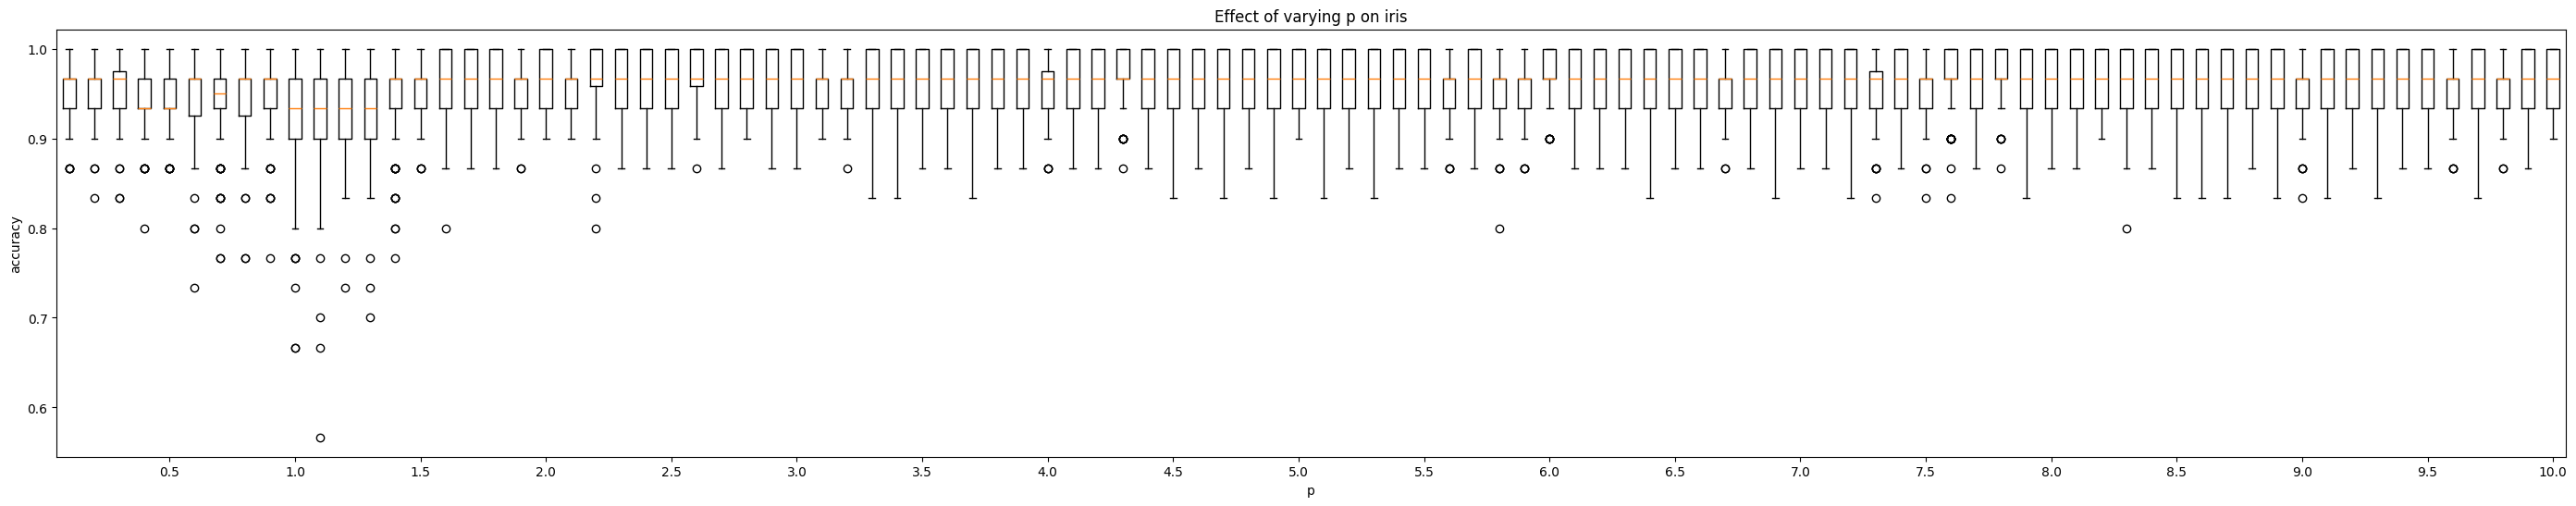

In [10]:
plt.figure(figsize=(35, 6))
plt.boxplot(iris_acc)
plt.xticks(xtick_value, xtick_label)
plt.title("Effect of varying p on iris")
plt.xlabel("p")
plt.ylabel("accuracy")
plt.show()

In [11]:
iris_name = ["sepal length", "sepal width", "petal length", "petal width"]
n = len(iris_name)
plot_idx = []
for i in range(0, n):
    for j in range(i + 1, n):
        plot_idx.append((i, j))
# plot_idx [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]

In [60]:
Ps[9]

np.float64(1.0)

In [65]:
train = iris_result[Ps[-1]]['train']
test = iris_result[Ps[-1]]['test']
model = iris_result[Ps[-1]]['model']

In [44]:
def visualize(model, train, test, i, j, variable_name, title, save=False):
    """
    Plot a 2d scatter plot of the given train and test dataset at the ith and jth dimension.
    Plot each node in the model as ellipsoid on the same plain.

    Parameters
    model (VEBF) : A vebf model containing zero or more node.
    train (np.ndarray) (n, 2) : Train dataset containing n samples, each sample is a tuple of (points, label) where points is an d-dim array
    test (np.ndarray) (n, 2) : Same as train.
    i (int) : index of the first dimension to plot the scatter plot and ellipsoid.
    j (int) : index of the second dimension to plot the scatter plot and ellipsoid.
    variable_name (list) : A list of variable names.
    title (str) : Title of the graph
    save (bool) : Set to True to save the plot. 
    """

    # separate the points by class label and set the scatter plot colour for each class
    colours = {}
    train_points = defaultdict(list)
    test_points = defaultdict(list)
    for point, label in train:
        train_points[label].append(point[[i, j]])
        colours.setdefault(label, len(colours))
    for point, label in test:
        test_points[label].append(point[[i, j]])
        colours.setdefault(label, len(colours))

    # scatter plot
    norm = mcolors.Normalize(vmin=0, vmax=len(colours) - 1)
    fig, ax = plt.subplots()
    for label, points in train_points.items():
        c = [colours[label]] * len(points)
        points = np.array(points)
        ax.scatter(points[:, 0], points[:, 1], label=f"{str(label)}", marker='v', c=c, cmap="tab10", norm=norm)
    for label, points in test_points.items():
        c = [colours[label]] * len(points)
        points = np.array(points)
        ax.scatter(points[:, 0], points[:, 1], label=f"{str(label)}", marker='^', c=c, cmap="tab10", norm=norm)
    legend_elements = [
    Line2D([0], [0], marker='v', label='Train', markersize=8, color='w', markerfacecolor='b'),
    Line2D([0], [0], marker='^', label='Test',  markersize=8, color='w', markerfacecolor='b')
    ]

    # plot the ellipsoids
    for node in model.get_nodes():
        y = node.label
        C = node.M[[i, j]]
        P = node.p[[i, j]]
        A = node.A
        U = node.U
        # sort the axes by length
        idx = np.argsort(A)[::-1]
        A = node.A[idx[:2]]
        U = U[:, idx]
        a1,a2 = A[:2]
        u1 = U[[i, j], 0]
        u2 = U[[i, j], 1]
        u1 = u1 / np.linalg.norm(u1)
        u2 = u2 / np.linalg.norm(u2)
        # Remove u1 component from u2, then normalize (Gram-Schmidt)
        u2 = u2 - np.dot(u2, u1) * u1
        u2 = u2 / np.linalg.norm(u2)
        U = np.column_stack([u1, u2])

        """print(f"Node {node.label}:")
        print(f"  C={C}")
        print(f"  A={A}")
        print(f"  P={P}")
        print(f"  U=\n{U}")
        print(f"  u1 norm={np.linalg.norm(u1):.4f}, u2 norm={np.linalg.norm(u2):.4f}")
        print(f"  u1·u2 dot={np.dot(u1,u2):.4f}")"""

        #A = np.array([a1, a2])
        #print(C, U, A, "\n")

        #l1, l2 = A * 2
        #angle = np.degrees(np.arctan2(u1[1] * l1, u1[0] * l1))
        #ax.add_patch(Ellipse(xy=C, width=l1, height=l2, angle=angle, fill=False))
        
        ax = plot_superellipsoid_2d(C=C, U=U, A=A, P=P, ax=ax, resolution=500)

    ax.set_aspect('equal')
    plt.axis('equal')
    plt.title(title)
    plt.xlabel(variable_name[i])
    plt.ylabel(variable_name[j])
    plt.legend(handles=legend_elements, title="Dataset")
    if save:
        plt.savefig(title + ".png")
    plt.show()


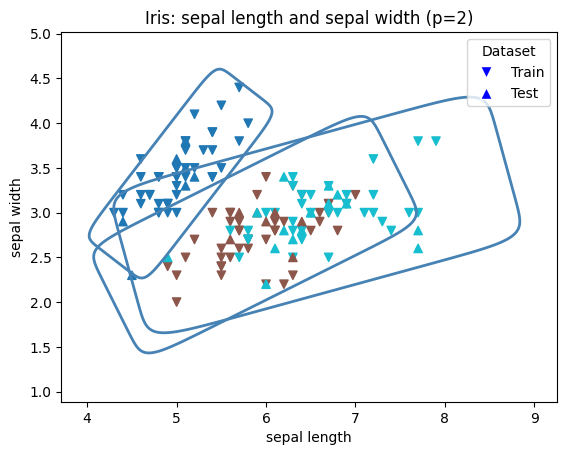

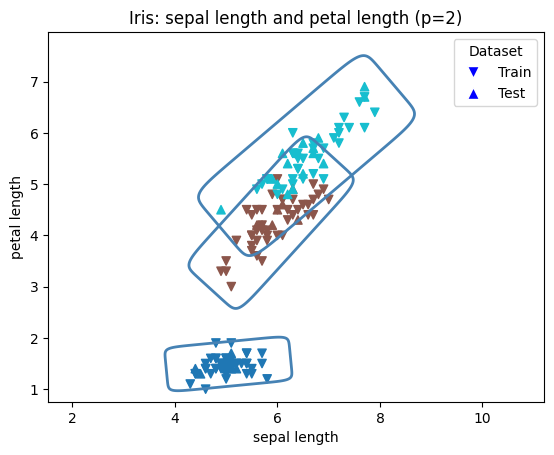

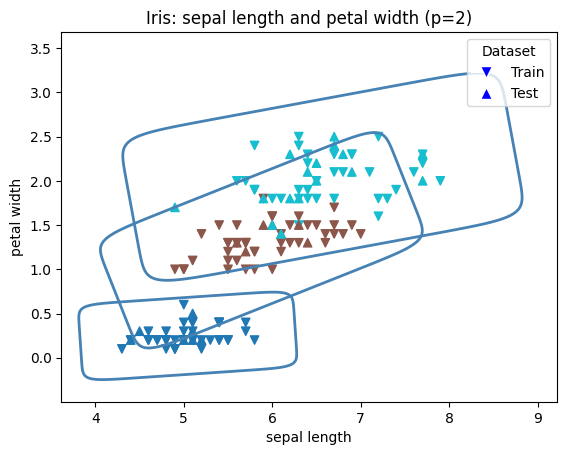

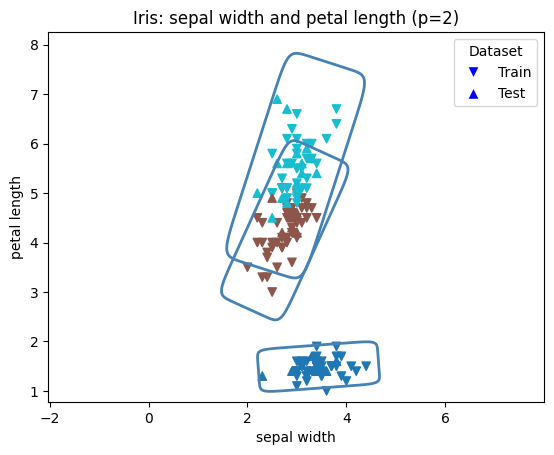

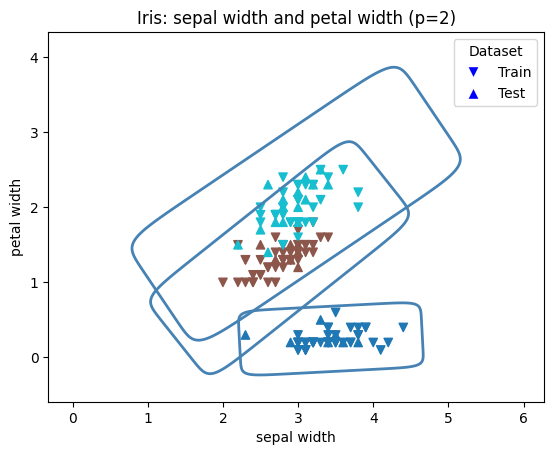

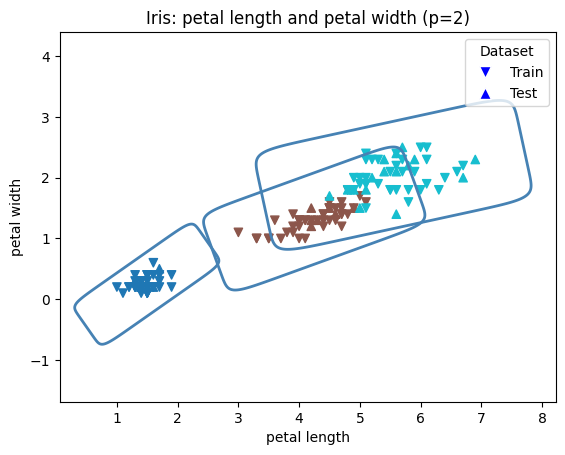

In [66]:
for i, j in plot_idx:
    title = f"Iris: {iris_name[i]} and {iris_name[j]} (p=2)"
    visualize(model, train, test, i, j, iris_name, title)

# Replicating baseline result (p=2)

In [7]:
iris_result = {}
for i in range(100):

    # shuffle the train/test split
    iris_train, iris_test = train_test_split(iris_ds)
    model = VEBF(dimension=4, merge_parameter=0., default_width=iris_A, p=iris_P)
    for idx in range(len(iris_train)):
        x,y = iris_train[idx]
        x = np.array(x,dtype=float)
        model.train(x, y)

    # test the model
    correct = 0
    for x, label in iris_test:
        pred = model.predict(x)
        if pred == label:
            correct += 1
    
    iris_result[i] = {"acc": correct/len(iris_test)}

In [13]:
ecoli_result = {}
for i in range(100):

    # shuffle the order in which the data is presented
    ecoli_train, ecoli_test = train_test_split(ecoli_ds)
    model = VEBF(dimension=7, merge_parameter=0., default_width=ecoli_A, p=ecoli_P)
    for idx in range(len(ecoli_train)):
        x,y = ecoli_train[idx]
        x = np.array(x,dtype=float)
        model.train(x, y)

    # test the model
    correct = 0
    for x, label in ecoli_test:
        pred = model.predict(x)
        if pred == label:
            correct += 1
    
    ecoli_result[i] = {"acc": correct/len(ecoli_test)}

In [11]:
yeast_result = {}
for i in range(100):

    # shuffle the order in which the data is presented
    yeast_train, yeast_test = train_test_split(yeast_ds)
    model = VEBF(dimension=8, merge_parameter=0., default_width=yeast_A, p=yeast_P)
    for idx in range(len(yeast_train)):
        x,y = yeast_train[idx]
        x = np.array(x,dtype=float)
        model.train(x, y)

    # test the model
    correct = 0
    for x, label in yeast_test:
        pred = model.predict(x)
        if pred == label:
            correct += 1
    
    yeast_result[i] = {"acc": correct/len(yeast_test)}

In [12]:
wave_result = {}
for i in range(100):

    # shuffle the order in which the data is presented
    wave_train, wave_test = train_test_split(waveform_ds)
    model = VEBF(dimension=21, merge_parameter=0., default_width=wave_A, p=wave_P)
    for idx in range(len(wave_train)):
        x,y = wave_train[idx]
        x = np.array(x,dtype=float)
        model.train(x, y)

    # test the model
    correct = 0
    for x, label in wave_test:
        pred = model.predict(x)
        if pred == label:
            correct += 1
    
    wave_result[i] = {"acc": correct/len(wave_test)}

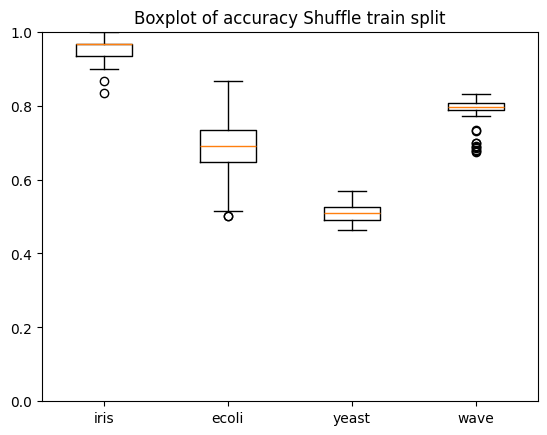

In [14]:
iris_acc = []
ecoli_acc = []
seg_acc = []
wave_acc = []
yeast_acc = []

for _, result in iris_result.items():
    iris_acc.append(result["acc"])
for _, result in ecoli_result.items():
    ecoli_acc.append(result["acc"])
for _, result in yeast_result.items():
    yeast_acc.append(result["acc"])
for _, result in wave_result.items():
    wave_acc.append(result["acc"])

plt.boxplot([iris_acc, ecoli_acc, yeast_acc, wave_acc])
plt.xticks([1, 2, 3, 4], ["iris", "ecoli", "yeast", "wave"])
plt.ylim(0, 1)
plt.title("Boxplot of accuracy Shuffle train split")
plt.show()